In [ ]:
# This is based on Phillip Lippe's for Amsterdam University (https://colab.research.google.com/github/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial2/Introduction_to_PyTorch.ipynb)
# and the Pytorch tutorial on embeddings (https://colab.research.google.com/github/pytorch/tutorials/blob/gh-pages/_downloads/363afc3b7c522e4e56981679c22f1ad6/word_embeddings_tutorial.ipynb)

# Pràctica 0: Introducció a PyTorch i aplicació a CBOW

Benvinguts i benvingudes al primer tutorial pràctic de **PyTorch** per a l'assignatura de **Tractament de la Veu i el Diàleg (TVD)**.

L'objectiu principal d'aquest *notebook* és familiaritzar-vos amb els fonaments d'un dels entorns de treball de referència en el desenvolupament de xarxes neuronals i aprenentatge profund. A través d'un enfocament pràctic, aprendreu a construir, entrenar i avaluar models pas a pas.

Aquest tutorial està estructurat en dues parts principals:

1. **Introducció a PyTorch i entrenament de la primera xarxa neuronal:**  
   Explorarem l'ús de tensors, les funcions de pèrdua, els optimitzadors i la dinàmica de retropropagació (*backpropagation*) mitjançant la construcció d'un model bàsic.

2. **Cas pràctic: Entrenament d'un model Continuous Bag-of-Words (CBOW):**  
   Aplicarem els conceptes de la primera secció al Processament del Llenguatge Natural (PLN). Aprendretingueu a representar el text com a vectors densos (*word embeddings*) i a entrenar un model capaç de predir una paraula a partir del seu context.

In [ ]:
## Standard libraries
import os
import math
import numpy as np
import time

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg', 'pdf') # For export
from matplotlib.colors import to_rgba
import seaborn as sns
sns.set()

## Progress bar
from tqdm.notebook import tqdm

/tmp/ipykernel_1226/47578708.py:11: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('svg', 'pdf') # For export


In [ ]:
import torch
print("Using torch", torch.__version__)

Using torch 2.11.0+cu128


### Tensors

Els tensors són l'equivalent a PyTorch de les matrius (arrays) de NumPy, amb l'afegit que també tenen suport per a l'acceleració per GPU (més sobre això més endavant).
El nom "tensor" és una generalització de conceptes que ja coneixeu. Per exemple, un vector és un tensor d'1 dimensió (1-D) i una matriu és un tensor de 2 dimensions (2-D). Quan treballem amb xarxes neuronals, utilitzarem tensors de diverses formes i nombres de dimensions.

La majoria de les funcions més comunes que coneixeu de NumPy també es poden utilitzar amb tensors. De fet, com que les matrius de NumPy són tan similars als tensors, podem convertir la majoria de tensors a matrius de NumPy (i a l'inrevés), tot i que no ho necessitem gaire sovint.

#### Inicialització

Comencem primer mirant diferents maneres de crear un tensor. Hi ha moltes opcions possibles; la més simple és cridar `torch.Tensor` passant la forma (shape) desitjada com a argument d'entrada:

In [ ]:
x = torch.Tensor(2, 3, 4)
print(x)

tensor([[[ 8.6010e+07,  4.3510e-41,  8.6010e+07,  4.3510e-41],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  1.5642e-39,  0.0000e+00,  0.0000e+00]],

        [[ 0.0000e+00,  0.0000e+00, -2.2649e+08,  1.5620e-39],
         [ 0.0000e+00,  1.3300e-37,  2.3822e-44,  2.9336e-30],
         [ 2.5399e-33,  2.5646e-33,  1.5746e-39,  0.0000e+00]]])


La funció `torch.Tensor` assigna memòria per al tensor desitjat, però reutilitza qualsevol valor que ja hi hagués a la memòria. Per assignar valors directament al tensor durant la inicialització, hi ha moltes alternatives que inclouen:

* `torch.zeros`: Crea un tensor omplert de zeros
* `torch.ones`: Crea un tensor omplert d'uns
* `torch.rand`: Crea un tensor amb valors aleatoris mostrejats de manera uniforme entre 0 i 1
* `torch.randn`: Crea un tensor amb valors aleatoris mostrejats d'una distribució normal amb mitjana 0 i variància 1
* `torch.arange`: Crea un tensor que conté els valors $N,N+1,N+2,...,M$
* `torch.Tensor` (llista d'entrada): Crea un tensor a partir dels elements de la llista que li proporcioneu

In [ ]:
# Create a tensor from a (nested) list
x = torch.Tensor([[1, 2], [3, 4]])
print(x)

tensor([[1., 2.],
        [3., 4.]])


In [ ]:
# Create a tensor with random values between 0 and 1 with the shape [2, 3, 4]
x = torch.rand(2, 3, 4)
print(x)

tensor([[[0.9798, 0.9909, 0.5879, 0.7473],
         [0.8148, 0.1074, 0.9663, 0.9566],
         [0.7035, 0.1877, 0.5038, 0.5235]],

        [[0.1790, 0.3039, 0.4519, 0.3862],
         [0.1842, 0.8551, 0.3617, 0.6878],
         [0.0952, 0.5863, 0.6382, 0.6318]]])


Podeu obtenir la forma d'un tensor de la mateixa manera que a NumPy (`x.shape`), o utilitzant el mètode `.size()`:

In [ ]:
shape = x.shape
print("Shape:", x.shape)

size = x.size()
print("Size:", size)

dim1, dim2, dim3 = x.size()
print("Size:", dim1, dim2, dim3)

Shape: torch.Size([2, 3, 4])
Size: torch.Size([2, 3, 4])
Size: 2 3 4


#### De Tensor a NumPy, i de NumPy a Tensor

Els tensors es poden convertir a matrius de NumPy, i les matrius de NumPy es poden tornar a convertir a tensors. Per transformar una matriu de NumPy en un tensor, podem utilitzar la funció `torch.from_numpy`:

In [ ]:
np_arr = np.array([[1, 2], [3, 4]])
tensor = torch.from_numpy(np_arr)

print("Numpy array:", np_arr)
print("PyTorch tensor:", tensor)

Numpy array: [[1 2]
 [3 4]]
PyTorch tensor: tensor([[1, 2],
        [3, 4]])


Per tornar a transformar un tensor de PyTorch a una matriu de NumPy, podem utilitzar la funció `.numpy()` als tensors:

In [ ]:
tensor = torch.arange(4)
np_arr = tensor.numpy()

print("PyTorch tensor:", tensor)
print("Numpy array:", np_arr)

PyTorch tensor: tensor([0, 1, 2, 3])
Numpy array: [0 1 2 3]


La conversió de tensors a NumPy requereix que el tensor estigui a la CPU i no a la GPU (més informació sobre el suport de GPU en una secció posterior). En cas que tingueu un tensor a la GPU, cal cridar `.cpu()` al tensor prèviament. Per tant, obtindreu una línia com ara `np_arr = tensor.cpu().numpy()`.

#### Operacions

La majoria de les operacions que existeixen a NumPy també existeixen a PyTorch. Es pot trobar una llista completa d'operacions a la [documentació de PyTorch](https://pytorch.org/docs/stable/tensors.html#), però aquí en revisarem les més importants.

Cridar `x1 + x2` crea un nou tensor que conté la suma de les dues entrades. No obstant això, també podem utilitzar operacions *in-place* (in situ) que s'apliquen directament sobre la memòria d'un tensor. Per tant, canviem els valors de `x2` sense la possibilitat de tornar a accedir als valors de `x2` d'abans de l'operació. A continuació es mostra un exemple:

In [ ]:
x1 = torch.rand(2, 3)
x2 = torch.rand(2, 3)

print("X1 before", x1)
print("X2 before", x2)
x2 + x1
print("X1 after +", x1)
print("X2 after +", x2)

x2.add_(x1)
print("X1 after add", x1)
print("X2 after add", x2)

X1 before tensor([[0.0080, 0.1475, 0.1085],
        [0.8037, 0.2911, 0.3415]])
X2 before tensor([[0.3038, 0.0497, 0.8057],
        [0.7406, 0.2689, 0.3098]])
X1 after + tensor([[0.0080, 0.1475, 0.1085],
        [0.8037, 0.2911, 0.3415]])
X2 after + tensor([[0.3038, 0.0497, 0.8057],
        [0.7406, 0.2689, 0.3098]])
X1 after add tensor([[0.0080, 0.1475, 0.1085],
        [0.8037, 0.2911, 0.3415]])
X2 after add tensor([[0.3117, 0.1972, 0.9141],
        [1.5443, 0.5600, 0.6513]])


Les operacions *in-place* solen estar marcades amb un sufix de guió baix (per exemple, "add_" en lloc de "add").

Una altra operació comuna té com a objectiu canviar la forma d'un tensor. Un tensor de mida (2,3) es pot reorganitzar a qualsevol altra forma amb el mateix nombre d'elements (per exemple, un tensor de mida (6), o (3,2), ...). A PyTorch, aquesta operació s'anomena `view`:

In [ ]:
x = torch.arange(6)
print("X", x)

X tensor([0, 1, 2, 3, 4, 5])


In [ ]:
x = x.view(2, 3)
print("X", x)

X tensor([[0, 1, 2],
        [3, 4, 5]])


In [ ]:
x = x.permute(1, 0) # Swapping dimension 0 and 1
print("X", x)

X tensor([[0, 3],
        [1, 4],
        [2, 5]])


#### Indexació

Sovint ens trobem en la situació de haver de seleccionar una part d'un tensor. La indexació funciona exactament com a NumPy, així que provem-ho:

In [ ]:
x = torch.arange(12).view(3, 4)
print("X", x)

print(x[:, 1])

X tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
tensor([1, 5, 9])


### Suport de GPU

Una característica crucial de PyTorch és el suport de les GPU, sigles en anglès de unitat de processament gràfic (*Graphics Processing Unit*). Una GPU pot executar molts milers de petites operacions en paral·lel, cosa que la fa molt adequada per dur a terme grans operacions matricials en xarxes neuronals.

Tant les CPU com les GPU tenen diferents avantatges i desavantatges, motiu pel qual molts ordinadors contenen tots dos components i els utilitzen per a diferents tasques. En cas que no estigueu familiaritzats amb les GPU, podeu llegir més detalls en aquesta [publicació del bloc de NVIDIA](https://blogs.nvidia.com/blog/2009/12/16/whats-the-difference-between-a-cpu-and-a-gpu/) o [aquí](https://www.intel.com/content/www/us/en/products/docs/processors/what-is-a-gpu.html).

Les GPU poden accelerar l'entrenament de la vostra xarxa fins a un factor de $100$, la qual cosa és essencial per a xarxes neuronals grans. PyTorch implementa moltes funcionalitats per donar suport a les GPU (sobretot a les de NVIDIA gràcies a les biblioteques [CUDA](https://developer.nvidia.com/cuda-zone) i [cuDNN](https://developer.nvidia.com/cudnn)). Primer de tot, comprovem si teniu una GPU disponible:

In [ ]:
gpu_avail = torch.cuda.is_available()
device = 'cuda:0' if gpu_avail else 'cpu'
print(f"Is the GPU available? {gpu_avail}")


Is the GPU available? True


# Primer Exemple:  XOR  Continu

Si volem construir una xarxa neuronal a PyTorch, podríem especificar tots els nostres paràmetres (matrius de pesos, vectors de biaix) utilitzant `Tensors` (amb `requires_grad=True`), demanar a PyTorch que calculi els gradients i després ajustar els paràmetres. Però les coses es poden complicar ràpidament si tenim molts paràmetres. A PyTorch, hi ha un paquet anomenat `torch.nn` que fa que la construcció de xarxes neuronals sigui més còmoda.

Introduirem les biblioteques i totes les parts addicionals que podríeu necessitar per entrenar una xarxa neuronal a PyTorch, utilitzant un classificador d'exemple senzill sobre un exemple simple però ben conegut: XOR. Dades dues entrades binàries $x_1$ i $x_2$, l'etiqueta a predir és $1$ si $x_1$ o $x_2$ és $1$ mentre que l'altra és $0$, o bé l'etiqueta és $0$ en tots els altres casos. L'exemple es va fer famós pel fet que una sola neurona, és a dir, un classificador lineal, no pot aprendre aquesta funció tan simple.
Per tant, aprendrem a construir una xarxa neuronal petita que pugui aprendre aquesta funció.
Per fer-ho un mica més interessant, traslladarem la funció XOR a un espai continu i introduirem una mica de soroll gaussià a les entrades binàries.

### El model

El paquet `torch.nn` defineix una sèrie de classes útils com ara capes de xarxes lineals, funcions d'activació, funcions de pèrdua, etc. Es pot trobar una llista completa [aquí](https://pytorch.org/docs/stable/nn.html). En cas que necessiteu una capa de xarxa determinada, consulteu primer la documentació del paquet abans d'escriure la capa vosaltres mateixos, ja que és molt probable que el paquet ja en contingui el codi. L'importem a continuació:

In [ ]:
import torch.nn as nn

A més de `torch.nn`, també hi ha `torch.nn.functional`. Aquest conté funcions que s'utilitzen a les capes de la xarxa. Això contrasta amb `torch.nn`, que les defineix com a `nn.Modules` (més informació a continuació), i de fet `torch.nn` utilitza moltes funcionalitats de `torch.nn.functional`. Per tant, el paquet funcional és útil en moltes situacions, així que també l'importem aquí.

In [ ]:
import torch.nn.functional as F

#### nn.Module

A PyTorch, una xarxa neuronal es construeix a partir de mòduls. Els mòduls poden contenir altres mòduls, i una xarxa neuronal es considera un mòdul en si mateixa. La plantilla bàsica d'un mòdul és la següent:

In [ ]:
class MyModule(nn.Module):

    def __init__(self):
        super().__init__()
        # Some init for my module

    def forward(self, x):
        # Function for performing the calculation of the module.
        pass

La funció `forward` és on té lloc el càlcul del mòdul, i s'executa quan crideu el mòdul (`nn = MyModule(); nn(x)`). A la funció `init`, normalment creem els paràmetres del mòdul utilitzant `nn.Parameter`, o bé definint altres mòduls que s'utilitzen a la funció `forward`. El càlcul cap enrere (*backward*) es fa automàticament, però també es podria sobreescriure si es volgués.

#### Classificador simple
Ara podem utilitzar els mòduls predefinits del paquet `torch.nn` i definir la nostra pròpia xarxa neuronal petita. Utilitzarem una xarxa mínima amb una capa d'entrada, una capa oculta amb `tanh` com a funció d'activació i una capa d'eixida (sortida). En altres paraules, la nostra xarxa hauria de tenir un aspecte similar a aquest:

<center width="100%"><img src="small_neural_network.svg" width="300px"></center>

Les neurones d'entrada es mostren en blau, les quals representen les coordenades $x_1$ i $x_2$ d'un punt de dades. Les neurones ocultes, incloent-hi l'activació `tanh`, es mostren en blanc, i la neurona de sortida en vermell.
A PyTorch, ho podem definir de la manera següent:

In [ ]:
class SimpleClassifier(nn.Module):

    def __init__(self, num_inputs, num_hidden, num_outputs):
        super().__init__()
        # Initialize the modules we need to build the network
        self.linear1 = nn.Linear(num_inputs, num_hidden)
        self.act_fn = nn.Tanh()
        self.linear2 = nn.Linear(num_hidden, num_outputs)

    def forward(self, x):
        # Perform the calculation of the model to determine the prediction
        x = self.linear1(x)
        x = self.act_fn(x)
        x = self.linear2(x)
        return x

Per als exemples d'aquest quadern (notebook), utilitzarem una xarxa neuronal molt petita amb dues neurones d'entrada i quatre neurones ocultes. Com que fem una classificació binària, utilitzarem una sola neurona de sortida. Fixeu-vos que encara no apliquem una funció sigmoide a la sortida. Això és degut a la resta de funcions, especialment la de pèrdua, que són més eficients i precises de calcular sobre les sortides originals en lloc de la sortida de la sigmoide. Més endavant en discutirem el motiu detallat.

In [ ]:
model = SimpleClassifier(num_inputs=2, num_hidden=4, num_outputs=1)
# Printing a module shows all its submodules
print(model)

SimpleClassifier(
  (linear1): Linear(in_features=2, out_features=4, bias=True)
  (act_fn): Tanh()
  (linear2): Linear(in_features=4, out_features=1, bias=True)
)


### Les dades

PyTorch també proporciona algunes funcionalitats per carregar les dades d'entrenament i de prova de manera eficient, resumides al paquet `torch.utils.data`.

In [ ]:
import torch.utils.data as data

El paquet de dades defineix dues classes que són la interfície estàndard per a la gestió de dades a PyTorch: `data.Dataset` i `data.DataLoader`. La classe *dataset* proporciona una interfície uniforme per accedir a les dades d'entrenament/prova, mentre que el *data loader* s'assegura de carregar i apilar eficientment els punts de dades del conjunt de dades en lots (batches) durant l'entrenament.

#### La classe dataset

La classe *dataset* resumeix la funcionalitat bàsica d'un conjunt de dades d'una manera natural. Per definir un conjunt de dades a PyTorch, només hem d'especificar dues funcions: `__getitem__` i `__len__`. La funció *get-item* ha de retornar l'í-ssim ($i$-è) punt de dades del conjunt de dades, mentre que la funció *len* retorna la mida del conjunt de dades. Per al conjunt de dades XOR, podem definir la classe dataset de la manera següent:

In [ ]:
class XORDataset(data.Dataset):

    def __init__(self, size, std=0.1):
        """
        Inputs:
            size - Number of data points we want to generate
            std - Standard deviation of the noise (see generate_continuous_xor function)
        """
        super().__init__()
        self.size = size
        self.std = std
        self.generate_continuous_xor()

    def generate_continuous_xor(self):
        # Each data point in the XOR dataset has two variables, x and y, that can be either 0 or 1
        # The label is their XOR combination, i.e. 1 if only x or only y is 1 while the other is 0.
        # If x=y, the label is 0.
        data = torch.randint(low=0, high=2, size=(self.size, 2), dtype=torch.float32)
        label = (data.sum(dim=1) == 1).to(torch.long)
        # To make it slightly more challenging, we add a bit of gaussian noise to the data points.
        data += self.std * torch.randn(data.shape)

        self.data = data
        self.label = label

    def __len__(self):
        # Number of data point we have. Alternatively self.data.shape[0], or self.label.shape[0]
        return self.size

    def __getitem__(self, idx):
        # Return the idx-th data point of the dataset
        # If we have multiple things to return (data point and label), we can return them as tuple
        data_point = self.data[idx]
        data_label = self.label[idx]
        return data_point, data_label

Intentem crear un d'aquests conjunts de dades i inspeccionar-lo:

In [ ]:
dataset = XORDataset(size=200)
print("Size of dataset:", len(dataset))
print("Data point 0:", dataset[0])

Size of dataset: 200
Data point 0: (tensor([0.1241, 0.0989]), tensor(0))


In [ ]:
def visualize_samples(data, label):
    if isinstance(data, torch.Tensor):
        data = data.cpu().numpy()
    if isinstance(label, torch.Tensor):
        label = label.cpu().numpy()
    data_0 = data[label == 0]
    data_1 = data[label == 1]

    plt.figure(figsize=(4,4))
    plt.scatter(data_0[:,0], data_0[:,1], edgecolor="#333", label="Class 0")
    plt.scatter(data_1[:,0], data_1[:,1], edgecolor="#333", label="Class 1")
    plt.title("Dataset samples")
    plt.ylabel(r"$x_2$")
    plt.xlabel(r"$x_1$")
    plt.legend()

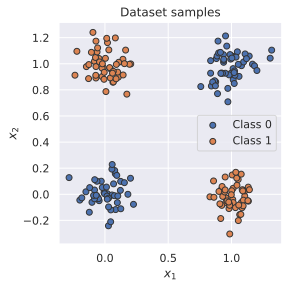

In [ ]:
visualize_samples(dataset.data, dataset.label)
plt.show()

#### La classe data loader

La classe `torch.utils.data.DataLoader` representa un iterable de Python sobre un conjunt de dades que inclou suport per a l'agrupació automàtica en lots (*batching*), la càrrega de dades multiprocés i moltes altres característiques. El *data loader* es comunica amb el conjunt de dades utilitzant la funció `__getitem__` i apila les seves sortides com a tensors sobre la primera dimensió per formar un lot.
A diferència de la classe *dataset*, normalment no hem de definir la nostra pròpia classe de *data loader*, sinó que simplement en podem crear un objecte passant-li el conjunt de dades com a entrada. A més, podem configurar el nostre *data loader* amb els arguments d'entrada següents (això és només una selecció, consulteu la llista completa [aquí](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader)):

* `batch_size`: Nombre de mostres a apilar per lot.
* `shuffle`: Si és `True`, les dades es retornen en un ordre aleatori. Això és important durant l'entrenament per introduir estocasticitat.
* `num_workers`: Nombre de subprocessos que s'utilitzaran per a la càrrega de dades. El valor per defecte, 0, significa que les dades es carregaran al procés principal, la qual cosa pot alentir l'entrenament en conjunts de dades on la càrrega d'un punt de dades requereix un temps considerable (per exemple, imatges grans). Es recomana utilitzar més *workers* per a aquests casos, però pot causar problemes en ordinadors amb Windows. Per a conjunts de dades molt petits com el nostre, 0 *workers* sol ser més ràpid.
* `pin_memory`: Si és `True`, el *data loader* copiarà els tensors a la memòria fixada (*pinned memory*) de CUDA abans de retornar-los. Això pot estalviar temps per a punts de dades grans a les GPU. Normalment és una bona pràctica utilitzar-ho per al conjunt d'entrenament, però no necessàriament per als de validació i prova per tal d'estalviar memòria a la GPU.
* `drop_last`: Si és `True`, el darrer lot es descarta en cas que sigui més petit que la mida de lot especificada. Això passa quan la mida del conjunt de dades no és un múltiple de la mida del lot. Només és potencialment útil durant l'entrenament per mantenir una mida de lot constant.

Creem un *data loader* senzill a continuació:

In [ ]:
data_loader = data.DataLoader(dataset, batch_size=8, shuffle=True)

In [ ]:
# next(iter(...)) catches the first batch of the data loader
# If shuffle is True, this will return a different batch every time we run this cell
# For iterating over the whole dataset, we can simple use "for batch in data_loader: ..."
data_inputs, data_labels = next(iter(data_loader))

# The shape of the outputs are [batch_size, d_1,...,d_N] where d_1,...,d_N are the
# dimensions of the data point returned from the dataset class
print("Data inputs", data_inputs.shape, "\n", data_inputs)
print("Data labels", data_labels.shape, "\n", data_labels)

Data inputs torch.Size([8, 2]) 
 tensor([[ 0.0187, -0.0376],
        [ 0.9500,  0.1324],
        [ 0.9863, -0.3039],
        [-0.2215,  1.0953],
        [ 1.0846,  0.0349],
        [ 0.0750, -0.0107],
        [ 0.1440,  0.9141],
        [-0.1464,  0.9778]])
Data labels torch.Size([8]) 
 tensor([0, 1, 1, 1, 1, 0, 1, 1])


### Optimization

After defining the model and the dataset, it is time to prepare the optimization of the model. During training, we will perform the following steps:

1. Get a batch from the data loader
2. Obtain the predictions from the model for the batch
3. Calculate the loss based on the difference between predictions and labels
4. Backpropagation: calculate the gradients for every parameter with respect to the loss
5. Update the parameters of the model in the direction of the gradients

We have seen how we can do step 1, 2 and 4 in PyTorch. Now, we will look at step 3 and 5.

#### Mòduls de loss

Podem calcular la pèrdua (*loss*) per a un lot simplement realitzant algunes operacions de tensors, ja que aquestes s'afegeixen automàticament al graf de computació. Per exemple, per a la classificació binària, podem utilitzar l'entropia creuada binària (*Binary Cross Entropy*, BCE), que es defineix de la manera següent:

$$\mathcal{L}_{BCE} = -\sum_i \left[ y_i \log x_i + (1 - y_i) \log (1 - x_i) \right]$$

on $y$ són les nostres etiquetes i $x$ les nostres prediccions, totes dues en l'interval de $[0,1]$. No obstant això, PyTorch ja proporciona una llista de funcions de pèrdua predefinides que podem utilitzar (consulteu [aquí](https://pytorch.org/docs/stable/nn.html#loss-functions) la llista completa). Per exemple, per a la BCE, PyTorch té dos mòduls: `nn.BCELoss()` i `nn.BCEWithLogitsLoss()`. Mentre que `nn.BCELoss` espera que les entrades $x$ estiguin en l'interval $[0,1]$ (és a dir, la sortida d'una sigmoide), `nn.BCEWithLogitsLoss` combina una capa sigmoide i la pèrdua BCE en una sola classe. Aquesta versió és numèricament més estable que utilitzar una sigmoide simple seguida d'una pèrdua BCE a causa dels logaritmes que s'apliquen a la funció de pèrdua. Per tant, es recomana utilitzar funcions de pèrdua aplicades sobre "logits" quan sigui possible (recordeu no aplicar cap sigmoide a la sortida del model en aquest cas!). Per al nostre model definit anteriorment, utilitzarem el mòdul `nn.BCEWithLogitsLoss`.

In [ ]:
loss_module = nn.BCEWithLogitsLoss()

Per actualitzar els paràmetres, PyTorch proporciona el paquet `torch.optim`, que té la majoria dels optimitzadors més populars ja implementats. Més endavant en el curs discutirem els optimitzadors específics i les seues diferències, però per ara utilitzarem el més senzill d'ells: `torch.optim.Adam`. Adam actualitza els paràmetres multiplicant els gradients per una petita constant, anomenada taxa d'aprenentatge (*learning rate*), i restant-los dels paràmetres (minimitzant així la pèrdua). D'aquesta manera, ens desplacem lentament en la direcció de minimitzar la pèrdua. Un bon valor per defecte de la taxa d'aprenentatge per a una xarxa petita com la nostra és 0,1.

In [ ]:
# Input to the optimizer are the parameters of the model: model.parameters()
import torch.optim as optim
optimizer = optim.Adam(model.parameters(), lr=0.1)

L'optimitzador proporciona dues funcions molt útils: `optimizer.step()` i `optimizer.zero_grad()`. La funció `step` actualitza els paràmetres basant-se en els gradients, tal com s'ha explicat anteriorment. La funció `optimizer.zero_grad()` estableix a zero els gradients de tots els paràmetres. Tot i que aquesta funció pot semblar menys rellevant a primera vista, és un pas previ crucial abans de realitzar la retropropagació. Si cridem la funció `backward` sobre la pèrdua quan els gradients dels paràmetres no són zero a causa del lot anterior, els nous gradients s'afegiran als anteriors en lloc de sobreescriure'ls. Això es fa així perquè un paràmetre pot aparèixer diverses vegades en un graf de computació i, en aquest cas, cal sumar els gradients en lloc de substituir-los. Per tant, recordeu cridar `optimizer.zero_grad()` abans de calcular els gradients d'un lot.

### Entrenament

Finalment, ja estem a punt per entrenar el nostre model. Com a primer pas, creem un conjunt de dades lleugerament més gran i especifiquem un *data loader* amb una mida de lot més gran.

In [ ]:
train_dataset = XORDataset(size=2500)
train_data_loader = data.DataLoader(train_dataset, batch_size=128, shuffle=True)

Ara, podem escriure una funció d'entrenament petita. Recordeu els nostres cinc passos: carregar un lot, obtenir les prediccions, calcular la pèrdua, fer la retropropagació i actualitzar. A més, hem d'enviar totes les dades i els paràmetres del model al dispositiu de la nostra elecció (GPU si està disponible). Per a la xarxa neuronal tan petita que tenim, comunicar les dades a la GPU de fet requereix molt més temps del que podríem estalviar executant l'operació a la CPU. Per a xarxes grans, el temps de comunicació és significativament menor que el temps d'execució real, la qual cosa fa que la GPU sigui crucial en aquests casos. Així i tot, per practicar, enviarem les dades a la GPU aquí.

In [ ]:
def train_model(model, optimizer, data_loader, loss_module, num_epochs=100):
    # Set model to train mode
    model.train()

    # Training loop
    for epoch in tqdm(range(num_epochs)):
        for data_inputs, data_labels in data_loader:

            ## Step 1: Move input data to device (only strictly necessary if we use GPU)
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)

            ## Step 2: Run the model on the input data
            preds = model(data_inputs)
            preds = preds.squeeze(dim=1) # Output is [Batch size, 1], but we want [Batch size]

            ## Step 3: Calculate the loss
            loss = loss_module(preds, data_labels.float())

            ## Step 4: Perform backpropagation
            # Before calculating the gradients, we need to ensure that they are all zero.
            # The gradients would not be overwritten, but actually added to the existing ones.
            optimizer.zero_grad()
            # Perform backpropagation
            loss.backward()

            ## Step 5: Update the parameters
            optimizer.step()

In [ ]:
model.to(device)
train_model(model, optimizer, train_data_loader, loss_module)

  0%|          | 0/100 [00:00<?, ?it/s]

### Avaluació

Una vegada hem entrenat un model, és hora d'avaluar-lo en un conjunt de prova independent (*held-out test set*). Com que el nostre conjunt de dades consta de punts de dades generats aleatòriament, primer hem de crear un conjunt de prova amb el seu corresponent *data loader*.

In [ ]:
test_dataset = XORDataset(size=500)
# drop_last -> Don't drop the last batch although it is smaller than 128
test_data_loader = data.DataLoader(test_dataset, batch_size=128, shuffle=False, drop_last=False)

Com a mètrica, utilitzarem la precisió (*accuracy*), la qual es calcula de la manera següent:

$$acc = \frac{\#\text{prediccions correctes}}{\#\text{totes les prediccions}} = \frac{TP+TN}{TP+TN+FP+FN}$$

on TP són els verdaders positius, TN els verdaders negatius, FP els falsos positius i FN els falsos negatius.

Quan avaluem el model, no cal fer un seguiment del graf de computació, ja que no tenim la intenció de calcular els gradients. Això redueix la memòria necessària i accelera el model. A PyTorch, podem desactivar el graf de computació utilitzant `with torch.no_grad(): ...`. Recordeu establir a més el model en mode d'avaluació (`eval`).

In [ ]:
def eval_model(model, data_loader):
    model.eval() # Set model to eval mode
    true_preds, num_preds = 0., 0.

    with torch.no_grad(): # Deactivate gradients for the following code
        for data_inputs, data_labels in data_loader:

            # Determine prediction of model on dev set
            data_inputs, data_labels = data_inputs.to(device), data_labels.to(device)
            preds = model(data_inputs)
            preds = preds.squeeze(dim=1)
            preds = torch.sigmoid(preds) # Sigmoid to map predictions between 0 and 1
            pred_labels = (preds >= 0.5).long() # Binarize predictions to 0 and 1

            # Keep records of predictions for the accuracy metric (true_preds=TP+TN, num_preds=TP+TN+FP+FN)
            true_preds += (pred_labels == data_labels).sum()
            num_preds += data_labels.shape[0]

    acc = true_preds / num_preds
    print(f"Accuracy of the model: {100.0*acc:4.2f}%")

In [ ]:
eval_model(model, test_data_loader)

Accuracy of the model: 100.00%


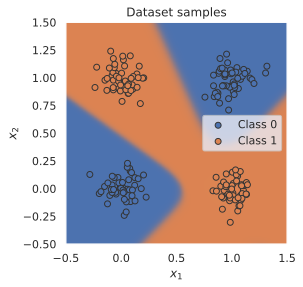

In [ ]:
@torch.no_grad() # Decorator, same effect as "with torch.no_grad(): ..." over the whole function.
def visualize_classification(model, data, label):
    if isinstance(data, torch.Tensor):
        data = data.cpu().numpy()
    if isinstance(label, torch.Tensor):
        label = label.cpu().numpy()
    data_0 = data[label == 0]
    data_1 = data[label == 1]

    fig = plt.figure(figsize=(4,4), dpi=500)
    plt.scatter(data_0[:,0], data_0[:,1], edgecolor="#333", label="Class 0")
    plt.scatter(data_1[:,0], data_1[:,1], edgecolor="#333", label="Class 1")
    plt.title("Dataset samples")
    plt.ylabel(r"$x_2$")
    plt.xlabel(r"$x_1$")
    plt.legend()

    # Let's make use of a lot of operations we have learned above
    model.to(device)
    c0 = torch.Tensor(to_rgba("C0")).to(device)
    c1 = torch.Tensor(to_rgba("C1")).to(device)
    x1 = torch.arange(-0.5, 1.5, step=0.01, device=device)
    x2 = torch.arange(-0.5, 1.5, step=0.01, device=device)
    xx1, xx2 = torch.meshgrid(x1, x2, indexing='ij')  # Meshgrid function as in numpy
    model_inputs = torch.stack([xx1, xx2], dim=-1)
    preds = model(model_inputs)
    preds = torch.sigmoid(preds)
    output_image = (1 - preds) * c0[None,None] + preds * c1[None,None]  # Specifying "None" in a dimension creates a new one
    output_image = output_image.cpu().numpy()  # Convert to numpy array. This only works for tensors on CPU, hence first push to CPU
    plt.imshow(output_image, origin='lower', extent=(-0.5, 1.5, -0.5, 1.5))
    plt.grid(False)
    return fig

_ = visualize_classification(model, dataset.data, dataset.label)
plt.show()

Incrustacions de paraules (Word Embeddings): Codificació de la semàntica lèxica
================================================================================

Els (*word embeddings*) són vectors densos de nombres reals, un per cada paraula del vostre vocabulari. En NLP, gairebé sempre passa que les vostres característiques són paraules! Però com s'ha de representar una paraula en un ordinador? Podríeu emmagatzemar la seua representació en caràcters ASCII, però això només us diu quina *és* la paraula, no diu gran cosa sobre què *significa* (podríeu ser capaços de derivar la seua categoria gramatical a partir dels seus afixos, o propietats a partir de l'ús de majúscules, però no gaire més). És més, en quin sentit podríeu combinar aquestes representacions? Sovint volem eixides (sortides) denses de les nostres xarxes neuronals quan les entrades tenen una dimensió de $|V|$, on $V$ és el nostre vocabulari, però sovint les eixides només tenen unes poques dimensions (si només estem predient un grapat d'etiquetes, per exemple). Com passem d'un espai de dimensions massives a un espai dimensional més petit?

Què tal si, en lloc de representacions ASCII, utilitzem una codificació *one-hot*? És a dir, representem la paraula $w$ per:

$$\overbrace{\left[ 0, 0, \dots, 1, \dots, 0, 0 \right]}^\text{|V| elements}$$

on l'1 es troba en una posició única per a $w$. Qualsevol altra paraula tindrà un 1 en alguna altra posició i un 0 a tota la resta.

Aquesta representació té un enorme inconvenient, a banda de com és de gegantina. Bàsicament tracta totes les paraules com a entitats independents sense cap relació entre elles. El que realment volem és una certa noció de *similaritat* entre paraules. Per què? Vegem un exemple.

Suposem que estem construint un model de llenguatge. Suposem que hem vist les frases següents a les nostres dades d'entrenament:

-   El matemàtic va córrer cap a la botiga.
-   El físic va córrer cap a la botiga.
-   El matemàtic va resoldre el problema obert.

Ara suposem que ens arriba una frase nova que mai abans s'havia vist a les nostres dades d'entrenament:

-   El físic va resoldre el problema obert.

El nostre model de llenguatge podria funcionar acceptablement bé amb aquesta frase, però no seria molt millor si poguéssim utilitzar els dos fets següents:

-   Hem vist *matemàtic* i *físic* en el mateix paper en una frase. De algun modo tenen una relació semàntica.
-   Hem vist *matemàtic* en el mateix paper en aquesta nova frase no vista on ara estem veient *físic*.

i després inferir que *físic* és realment una bona opció per a la nova frase no vista? A això ens referim amb una noció de similaritat: ens referim a *similaritat semàntica*, no simplement a tenir representacions ortogràfiques similars. És una tècnica per combatre la dispersió (*sparsity*) de les dades lingüístiques, connectant els punts entre allò que hem vist i allò que no. Aquest exemple, per descomptat, es basa en un supòsit lingüístic fonamental: que les paraules que apareixen en contextos similars estan relacionades semànticament entre si. Això s'anomena l'[hipòtesi distribucional](https://en.wikipedia.org/wiki/Distributional_semantics).

Obtenció d'embeddings densos de paraules
--------------------------------------------

Com podem resoldre aquest problema? És a dir, com podríem codificar realment la similaritat semàntica en les paraules? Potser podríem pensar en alguns atributs semàntics. Per exemple, veiem que tant els matemàtics com els físics poden córrer, així que potser dóna a aquestes paraules una puntuació alta per a l'atribut semàntic "és capaç de córrer". Penseu en altres atributs i imagineu quina puntuació podríeu assignar a algunes paraules comunes en aquests atributs.

Si cada atribut és una dimensió, podríem assignar un vector a cada paraula, com aquest:

$$q_\text{matemàtic} = \left[ \overbrace{2.3}^\text{pot córrer}, \overbrace{9.4}^\text{li agrada el cafè}, \overbrace{-5.5}^\text{s'ha graduat en Física}, \dots \right]$$

$$q_\text{físic} = \left[ \overbrace{2.5}^\text{pot córrer}, \overbrace{9.1}^\text{li agrada el cafè}, \overbrace{6.4}^\text{s'ha graduat en Física}, \dots \right]$$

Aleshores podem obtenir una mesura de similaritat entre aquestes paraules fent:

$$\text{Similaritat}(\text{físic}, \text{matemàtic}) = q_\text{físic} \cdot q_\text{matemàtic}$$

Encara que és més habitual normalitzar per les longituds:

$$\text{Similaritat}(\text{físic}, \text{matemàtic}) = \frac{q_\text{físic} \cdot q_\text{matemàtic}}{\| q_\text{físic} \| \| q_\text{matemàtic} \|} = \cos (\phi)$$

On $\phi$ és l'angle entre els dos vectors. D'aquesta manera, les paraules extremadament similars (paraules les incrustacions de les quals apunten en la mateixa direcció) tindran una similaritat d'1. Les paraules extremadament dissidents haurien de tenir una similaritat de -1.

Podeu pensar en els vectors dispersos *one-hot* del principi d'aquesta secció com un cas especial d'aquests nous vectors que hem definit, on cada paraula té bàsicament una similaritat de 0 i hem donat a cada paraula un atribut semàntic únic. Aquests nous vectors són *densos*, la qual cosa vol dir que les seues entrades són (típicament) diferents de zero.

Però aquests nous vectors són un gran dolor de cap: podríeu pensar en milers d'atributs semàntics diferents que podrien ser rellevants per determinar la similaritat, i com dimonis podríeu establir els valors dels diferents atributs? Un concepte central de l'aprenentatge profund (*deep learning*) és que la xarxa neuronal aprèn les representacions de les característiques, en lloc de requerir que el programador les dissenyi ell mateix. Així doncs, per què no deixar simplement que les incrustacions de paraules siguen paràmetres del nostre model i que s'actualitzen durant l'entrenament? Això és exactament el que farem. Tindrem uns certs *atributs semàntics latents* que la xarxa pot, en principi, aprendre. Cal tindre en compte que les incrustacions de paraules probablement no seran interpretables. És a dir, tot i que amb els nostres vectors fets a mà anteriors podem veure que els matemàtics i els físics són similars en el fet que a tots dos els agrada el cafè, si deixem que una xarxa neuronal aprengui les incrustacions i veiem que tant els matemàtics com els físics tenen un valor gran en la segona dimensió, no està clar què significa això. Són similars en alguna dimensió semàntica latent, però això probablement no té cap interpretació per a nosaltres.

En resum, **els embeddings de paraules són una representació de la \*semàntica\* d'una paraula, codificant de manera eficient la informació semàntica que podria ser rellevant per a la tasca que es duu a terme**. També podeu incrustar altres coses: etiquetes de categories gramaticals, arbres de sintaxi, qualsevol cosa! La idea de les incrustacions de característiques (*feature embeddings*) és central en aquest camp.

Embeddings de paraules a PyTorch
------------------------------------

Abans d'arribar a un exemple pràctic i a un exercici, unes quantes notes ràpides sobre com utilitzar els embeddings a PyTorch i en la programació d'aprenentatge profund en general. De manera similar a com definíem un índex únic per a cada paraula quan fèiem vectors *one-hot*, també hem de definir un índex per a cada paraula quan utilitzem incrustacions. Aquests seran claus en una taula de cerca (*lookup table*). És a dir, els embeddings s'emmagatzemen com una matriu de $|V| \times D$, on $D$ és la dimensionalitat de les incrustacions, de manera que la paraula assignada a l'índex $i$ té la seua incrustació emmagatzemada a la fila $i$-èssima de la matriu. En tot el meu codi, el mapa de paraules a índexs és un diccionari anomenat `word_to_ix`.

El mòdul que us permet utilitzar embeddingss és `torch.nn.Embedding`, el qual rep dos arguments: la mida del vocabulari i la dimensionalitat.

Per indexar en aquesta taula, heu d'utilitzar `torch.LongTensor` (ja que els índexs són enters, no nombres de punt flotant).


In [ ]:
word_to_ix = {"hello": 0, "world": 1}
embeds = nn.Embedding(2, 5)  # 2 words in vocab, 5 dimensional embeddings
lookup_tensor = torch.tensor([word_to_ix["hello"]], dtype=torch.long)
hello_embed = embeds(lookup_tensor)
print(hello_embed)

tensor([[ 0.4764, -0.7698, -0.9006, -1.3694,  2.2080]],
       grad_fn=<EmbeddingBackward0>)


Un exemple: Modelat del llenguatge amb N-grams
==============================================

Recordeu que en un model de llenguatge basat en n-grams, donada una seqüència de paraules $w$, volem calcular:

$$P(w_i | w_{i-1}, w_{i-2}, \dots, w_{i-n+1} )$$

On $w_i$ és la $i$-èssima paraula de la seqüència.

En aquest exemple, calcularem la funció de pèrdua (*loss function*) sobre alguns exemples d'entrenament i actualitzarem els paràmetres mitjançant retropropagació (*backpropagation*).


In [ ]:
CONTEXT_SIZE = 2
EMBEDDING_DIM = 10
# We will use Shakespeare Sonnet 2
test_sentence = """When forty winters shall besiege thy brow,
And dig deep trenches in thy beauty's field,
Thy youth's proud livery so gazed on now,
Will be a totter'd weed of small worth held:
Then being asked, where all thy beauty lies,
Where all the treasure of thy lusty days;
To say, within thine own deep sunken eyes,
Were an all-eating shame, and thriftless praise.
How much more praise deserv'd thy beauty's use,
If thou couldst answer 'This fair child of mine
Shall sum my count, and make my old excuse,'
Proving his beauty by succession thine!
This were to be new made when thou art old,
And see thy blood warm when thou feel'st it cold.""".split()
# we should tokenize the input, but we will ignore that for now
# build a list of tuples.
# Each tuple is ([ word_i-CONTEXT_SIZE, ..., word_i-1 ], target word)
ngrams = [
    (
        [test_sentence[i - j - 1] for j in range(CONTEXT_SIZE)],
        test_sentence[i]
    )
    for i in range(CONTEXT_SIZE, len(test_sentence))
]
# Print the first 3, just so you can see what they look like.
print(ngrams[:3])

vocab = set(test_sentence)
word_to_ix = {word: i for i, word in enumerate(vocab)}


class NGramLanguageModeler(nn.Module):

    def __init__(self, vocab_size, embedding_dim, context_size):
        super(NGramLanguageModeler, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.linear1 = nn.Linear(context_size * embedding_dim, 128)
        self.linear2 = nn.Linear(128, vocab_size)

    def forward(self, inputs):
        embeds = self.embeddings(inputs).view((1, -1))
        out = F.relu(self.linear1(embeds))
        out = self.linear2(out)
        log_probs = F.log_softmax(out, dim=1)
        return log_probs


losses = []
loss_function = nn.NLLLoss()
model = NGramLanguageModeler(len(vocab), EMBEDDING_DIM, CONTEXT_SIZE)
optimizer = optim.SGD(model.parameters(), lr=0.001)

for epoch in range(10):
    total_loss = 0
    for context, target in ngrams:

        # Step 1. Prepare the inputs to be passed to the model (i.e, turn the words
        # into integer indices and wrap them in tensors)
        context_idxs = torch.tensor([word_to_ix[w] for w in context], dtype=torch.long)

        # Step 2. Recall that torch *accumulates* gradients. Before passing in a
        # new instance, you need to zero out the gradients from the old
        # instance
        model.zero_grad()

        # Step 3. Run the forward pass, getting log probabilities over next
        # words
        log_probs = model(context_idxs)

        # Step 4. Compute your loss function. (Again, Torch wants the target
        # word wrapped in a tensor)
        loss = loss_function(log_probs, torch.tensor([word_to_ix[target]], dtype=torch.long))

        # Step 5. Do the backward pass and update the gradient
        loss.backward()
        optimizer.step()

        # Get the Python number from a 1-element Tensor by calling tensor.item()
        total_loss += loss.item()
    losses.append(total_loss)
print(losses)  # The loss decreased every iteration over the training data!

# To get the embedding of a particular word, e.g. "beauty"
print(model.embeddings.weight[word_to_ix["beauty"]])

[(['forty', 'When'], 'winters'), (['winters', 'forty'], 'shall'), (['shall', 'winters'], 'besiege')]
[520.1293654441833, 517.8007307052612, 515.4848051071167, 513.1810526847839, 510.88792276382446, 508.6048560142517, 506.33197140693665, 504.067697763443, 501.8116979598999, 499.5633146762848]
tensor([ 1.1645, -0.7397, -1.1693, -0.7228,  1.5929, -1.0748,  0.7633,  0.3293,
         0.4333,  0.7943], grad_fn=<SelectBackward0>)


Continuous Bag-of-Words
============================================================

El model de *Continuous Bag-of-Words* (CBOW)  intenta predir paraules donat el context d'algunes paraules anteriors i algunes paraules posteriors a la paraula objectiu. Això és diferent del modelat del llenguatge, ja que el CBOW no és seqüencial i no ha de ser necessàriament probabilístic. Típicament, el CBOW s'utilitza per entrenar ràpidament embeddings de paraules, i aquestes embeddings s'usen per inicialitzar les de models més complicats. Usualment, això es coneix com a *pretrained embeddings*. Quasi sempre ajuda a millorar el rendiment en un parell de punts percentuals.

El model CBOW funciona de la manera següent. Donada una paraula objectiu $w_i$ i una finestra de context de mida $N$ a cada costat, $w_{i-1}, \dots, w_{i-N}$ i $w_{i+1}, \dots, w_{i+N}$, referint-nos a totes les paraules del context de manera col·lectiva com a $C$, el CBOW intenta minimitzar:

$$-\log p(w_i | C) = -\log \text{Softmax}\left(A(\sum_{w \in C} q_w) + b\right)$$

on $q_w$ és l'*embedding* de la paraula $w$.

Implementeu aquest model a PyTorch omplint la classe següent. Alguns consells:

-   Penseu quins paràmetres heu de definir.
-   Assegureu-vos de saber quina forma (*shape*) espera cada operació. Utilitzeu `.view()` si us cal canviar-ne la forma.


In [ ]:
CONTEXT_SIZE = 2  # 2 words to the left, 2 to the right
EMBEDDING_DIM = 10
raw_text = """We are about to study the idea of a computational process.
Computational processes are abstract beings that inhabit computers.
As they evolve, processes manipulate other abstract things called data.
The evolution of a process is directed by a pattern of rules
called a program. People create programs to direct processes. In effect,
we conjure the spirits of the computer with our spells.""".split()

# By deriving a set from `raw_text`, we deduplicate the array
vocab = set(raw_text)
vocab_size = len(vocab)

word_to_ix = {word: i for i, word in enumerate(vocab)}
data = []
for i in range(CONTEXT_SIZE, len(raw_text) - CONTEXT_SIZE):
    context = (
        [raw_text[i - j - 1] for j in range(CONTEXT_SIZE)]
        + [raw_text[i + j + 1] for j in range(CONTEXT_SIZE)]
    )
    target = raw_text[i]
    data.append((context, target))
print(data[:5])


class CBOW(nn.Module):

    def __init__(self, vocab_size, embedding_dim):
        super(CBOW, self).__init__()
        #TODO

    def forward(self, inputs):
        #TODO

# Create your model and train. Here are some functions to help you make
# the data ready for use by your module.


def make_context_vector(context, word_to_ix):
    idxs = [word_to_ix[w] for w in context]
    return torch.tensor(idxs, dtype=torch.long)


make_context_vector(data[0][0], word_to_ix)  # example

# Initialize model, loss function, and optimizer
model = CBOW(vocab_size, EMBEDDING_DIM)
loss_function = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

# Training loop
for epoch in range(100):
    total_loss = 0
    for context, target in data:
        context_vector = make_context_vector(context, word_to_ix)
        #TODO
        loss = loss_function(log_probs, torch.tensor([word_to_ix[target]], dtype=torch.long))
        #TODO
        total_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch + 1}, Loss: {total_loss:.4f}')

[(['are', 'We', 'to', 'study'], 'about'), (['about', 'are', 'study', 'the'], 'to'), (['to', 'about', 'the', 'idea'], 'study'), (['study', 'to', 'idea', 'of'], 'the'), (['the', 'study', 'of', 'a'], 'idea')]
Epoch 10, Loss: 240.0339
Epoch 20, Loss: 214.3377
Epoch 30, Loss: 192.7631
Epoch 40, Loss: 174.5056
Epoch 50, Loss: 159.0229
Epoch 60, Loss: 145.8117
Epoch 70, Loss: 134.4203
Epoch 80, Loss: 124.4909
Epoch 90, Loss: 115.7505
Epoch 100, Loss: 107.9909


### Avaluació: Perplexitat

Per avaluar el vostre model CBOW utilitzant la perplexitat, primer hem d'entendre com s'aplica la perplexitat en aquest cas.

La perplexitat mesura com de sorprès està una distribució de probabilitat davant d'una seqüència de mostra. Formalment:

$$\text{Perplexitat} = \exp\left( -\frac{1}{M} \sum_{j=1}^{M} \log P(w_j \mid C_j) \right)$$

on $M$ és el nombre total de paraules objectiu avaluades, $C_j$ és la finestra de context que envolta la paraula objectiu $w_j$, i $\log P(w_j \mid C_j)$ és la log-probabilitat assignada a la paraula objectiu correcta pel vostre model (obtinguda directament mitjançant `nn.LogSoftmax` o `nn.NLLLoss`)

In [ ]:
def compute_perplexity(model, text_tokens, word_to_ix, context_size=2, unk_token="<UNK>"):
    model.eval()
    loss_function = nn.NLLLoss(reduction='sum')

    total_loss = 0.0
    total_words = 0
    oov_count = 0

    unk_idx = word_to_ix.get(unk_token, len(word_to_ix))

    with torch.no_grad():
        for i in range(context_size, len(text_tokens) - context_size):
            target_word = text_tokens[i]

            context_words = (
                [text_tokens[i - j - 1] for j in range(context_size)]
                + [text_tokens[i + j + 1] for j in range(context_size)]
            )

            if target_word not in word_to_ix:
                oov_count += 1

            target_idx = word_to_ix.get(target_word, unk_idx)
            context_idxs = [word_to_ix.get(w, unk_idx) for w in context_words]

            # If any word is OOV and model has no <UNK> token, skip this sample
            if target_idx >= model.embeddings.num_embeddings or any(idx >= model.embeddings.num_embeddings for idx in context_idxs):
                print(target_idx, len(vocab))
                continue

            context_tensor = torch.tensor(context_idxs, dtype=torch.long)
            target_tensor = torch.tensor([target_idx], dtype=torch.long)

            log_probs = model(context_tensor)
            loss = loss_function(log_probs, target_tensor)

            total_loss += loss.item()
            total_words += 1

    # Handled early return gracefully with mean_loss included
    if total_words == 0:
        return {
            "perplexity": float("inf"),
            "mean_loss": float("inf"),
            "evaluated_words": 0,
            "oov_count": oov_count
        }

    mean_loss = total_loss / total_words
    perplexity = math.exp(mean_loss)

    return {
        "perplexity": perplexity,
        "mean_loss": mean_loss,
        "evaluated_words": total_words,
        "oov_count": oov_count
    }

In [ ]:
def evaluate_text(model, text, word_to_ix, CONTEXT_SIZE=2):
    stats = compute_perplexity(model, text, word_to_ix, CONTEXT_SIZE)
    print(f"Perplexity: {stats['perplexity']:.4f}")
    print(f"Mean NLL Loss: {stats['mean_loss']:.4f}")
    print(f"Words Evaluated: {stats['evaluated_words']}\n")


In [ ]:
# 1. Evaluate on Known Sentence
print(f"--- Known Sentence ---")
known_text = "processes manipulate other abstract things called data.".split()
evaluate_text(model, known_text, word_to_ix, CONTEXT_SIZE=2)


print(f"--- Unknown Sentences ---")
# 2. Evaluate on Unknown Sentences
unknown_text1 = "programs create things called abstract data.".split()
evaluate_text(model, unknown_text1, word_to_ix, CONTEXT_SIZE=2)

unknown_text2 = "programs create processes to manipulate things".split()
evaluate_text(model, unknown_text2, word_to_ix, CONTEXT_SIZE=2)




--- Known Sentence ---
Perplexity: 5.6220
Mean NLL Loss: 1.7267
Words Evaluated: 3

--- Unknown Sentences ---
Perplexity: 27.7417
Mean NLL Loss: 3.3229
Words Evaluated: 2

Perplexity: 29.7636
Mean NLL Loss: 3.3933
Words Evaluated: 2




### Cloenda i pròxims passos

Amb aquest cas pràctic donem per finalitzat el primer tutorial de **PyTorch** per a l'assignatura de **Tractament de la Veu i el Diàleg (TVD)**.

Al llarg d'aquest *notebook*, hem après a:
* **Manejar els components bàsics de PyTorch:** tensors, capes lineals, funcions d'activació i optimitzadors.
* **Comprendre el flux d'entrenament:** des de la propagació cap endavant (*forward pass*), el càlcul de la pèrdua i la retropropagació (*backward pass*), fins a l'actualització dels paràmetres amb `optimizer.step()`.
* **Representar informació semàntica:** mitjançant l'ús de capes d'incrustació (*embeddings*) per transformar paraules discretes en vectors densos.
* **Entrenar i avaluar un model CBOW:** entenent com utilitzar el context per predir paraules i com mesurar-ne el rendiment mitjançant mètriques com la **perplexitat**.

Aquests fonaments seran essencials al llarg de l'assignatura quan treballem amb arquitectures més complexes adaptades al processament de la veu, el reconeixement de la parla i els sistemes de diàleg.

Us animem a experimentar amb el codi: proveu de modificar la mida dels embeddings (`EMBEDDING_DIM`), canviar la finestra de context (`CONTEXT_SIZE`), o aplicar el model a conjunts de dades de text més grans.